Shape: (25361, 4)

Class distribution:
OUTPUT
Abnormal    19579
Normal       5782
Name: count, dtype: int64

Mean per class:
             HR   SpO2   TEMP
OUTPUT                       
Abnormal  89.43  96.67  39.84
Normal    88.37  96.88  29.97

Label mapping:
  0 = Abnormal
  1 = Normal

Features used: 15

Train class counts: {'Abnormal': np.int64(15663), 'Normal': np.int64(4625)}
[0]	validation_0-logloss:0.45029
[10]	validation_0-logloss:0.15106
[20]	validation_0-logloss:0.06972
[30]	validation_0-logloss:0.04173
[40]	validation_0-logloss:0.03058
[49]	validation_0-logloss:0.02579

Training complete!
Accuracy: 0.9927 (99.27%)

              precision    recall  f1-score   support

    Abnormal       1.00      0.99      1.00      3916
      Normal       0.98      0.99      0.98      1157

    accuracy                           0.99      5073
   macro avg       0.99      0.99      0.99      5073
weighted avg       0.99      0.99      0.99      5073



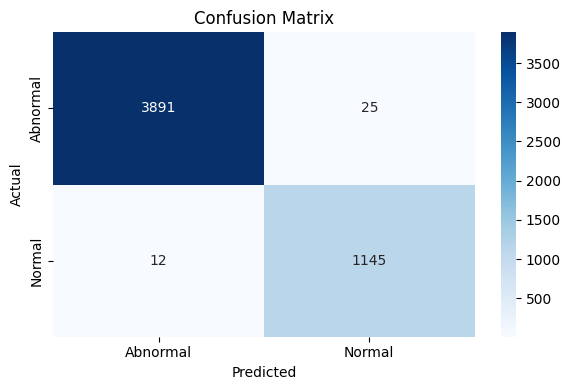

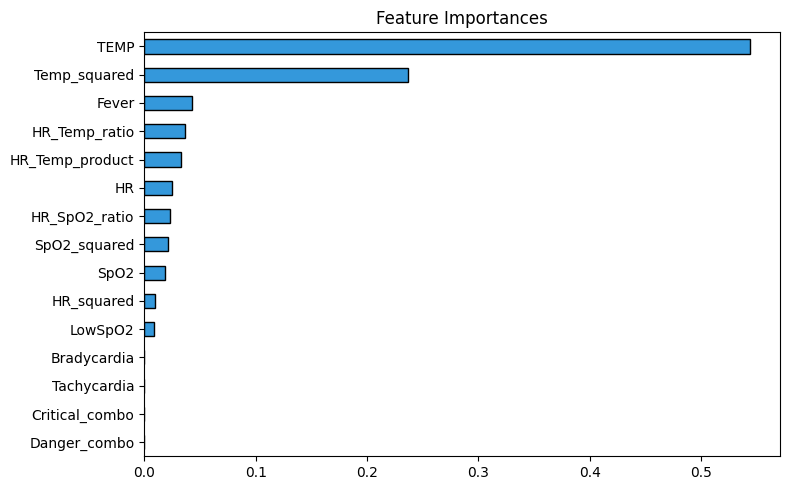

✅ xgb_model.cc saved!
   Trees: 50 | Features: 15 | Classes: 2
   File size: 69.58 KB
🚀 Ready for ESP32!


In [ ]:
import pandas as pd
import numpy as np
import json
import os
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder


df = pd.read_csv("Human_vital_signs_R.csv")
df.columns = df.columns.str.strip()
df = df[["HR", "SpO2", "TEMP", "OUTPUT"]].dropna()

print("Shape:", df.shape)
print("\nClass distribution:")
print(df["OUTPUT"].value_counts())
print("\nMean per class:")
print(df.groupby("OUTPUT")[["HR", "SpO2", "TEMP"]].mean().round(2))


df["HR_Temp_ratio"]   = df["HR"] / (df["TEMP"] + 1)
df["HR_SpO2_ratio"]   = df["HR"] / (df["SpO2"] + 1)
df["HR_squared"]      = df["HR"] ** 2
df["Temp_squared"]    = df["TEMP"] ** 2
df["SpO2_squared"]    = df["SpO2"] ** 2
df["HR_Temp_product"] = df["HR"] * df["TEMP"]
df["Fever"]           = (df["TEMP"] > 37.5).astype(int)
df["Tachycardia"]     = (df["HR"] > 100).astype(int)
df["Bradycardia"]     = (df["HR"] < 60).astype(int)
df["LowSpO2"]         = (df["SpO2"] < 95).astype(int)
df["Danger_combo"]    = df["Fever"] * df["Tachycardia"]
df["Critical_combo"]  = df["LowSpO2"] * df["Tachycardia"]

FEATURES = [
    "HR", "SpO2", "TEMP",
    "HR_Temp_ratio", "HR_SpO2_ratio",
    "HR_squared", "Temp_squared", "SpO2_squared",
    "HR_Temp_product",
    "Fever", "Tachycardia", "Bradycardia",
    "LowSpO2", "Danger_combo", "Critical_combo"
]

X = df[FEATURES]
y = df["OUTPUT"]

label_encoder = LabelEncoder()
y_enc = label_encoder.fit_transform(y)

print("\nLabel mapping:")
for i, cls in enumerate(label_encoder.classes_):
    print(f"  {i} = {cls}")
print("\nFeatures used:", len(FEATURES))


X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc, test_size=0.2, random_state=42, stratify=y_enc
)

n_classes    = len(label_encoder.classes_)
class_counts = np.bincount(y_train)
print("\nTrain class counts:", dict(zip(label_encoder.classes_, class_counts)))


is_binary = (n_classes == 2)

model = XGBClassifier(
    n_estimators=50,
    max_depth=4,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=3,
    gamma=0.1,
    objective="binary:logistic" if is_binary else "multi:softprob",
    num_class=None if is_binary else n_classes,
    eval_metric="logloss" if is_binary else "mlogloss",
    random_state=42
)

model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=10)
print("\nTraining complete!")

y_pred = model.predict(X_test)
acc    = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc:.4f} ({acc*100:.2f}%)")
print()
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title("Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()

feat_imp = pd.Series(model.feature_importances_, index=FEATURES).sort_values()
feat_imp.plot(kind="barh", figsize=(8, 5), color="#3498db", edgecolor="black")
plt.title("Feature Importances")
plt.tight_layout()
plt.show()


def export_to_c(model, feature_names, label_classes, filename="xgb_model.cc"):
    booster    = model.get_booster()
    trees_dump = booster.get_dump(dump_format='json')
    n_cls      = len(label_classes)
    is_binary  = (n_cls == 2)

    lines = [
        "#include <math.h>",
        "#include <string.h>",
        "",
    ]

    if is_binary:
        lines += [
            "static float _sigmoid(float x) {",
            "    if (x<0.0f){float z=expf(x);return z/(1.0f+z);}",
            "    return 1.0f/(1.0f+expf(-x));",
            "}", "",
        ]
    else:
        lines += [
            "static void _softmax(float* a, int n) {",
            "    float mx=a[0]; for(int i=1;i<n;i++) if(a[i]>mx) mx=a[i];",
            "    float s=0; for(int i=0;i<n;i++){a[i]=expf(a[i]-mx);s+=a[i];}",
            "    for(int i=0;i<n;i++) a[i]/=s;",
            "}", "",
        ]

    lines += ["static void _score(float* inp, float* out) {"]
    if is_binary:
        lines.append("    float sum=0.0f;")
    else:
        lines.append(f"    memset(out,0,sizeof(float)*{n_cls});")
    lines.append("")

    def parse_node(node, indent=8):
        pad = " " * indent
        r   = []
        if "leaf" in node:
            if is_binary:
                r.append(f"{pad}sum+={node['leaf']:.8f}f;")
            else:
                r.append(f"{pad}tv={node['leaf']:.8f}f;")
        else:
            feat = node["split"]
            fi   = feature_names.index(feat) if feat in feature_names else int(feat.replace("f", ""))
            th   = node["split_condition"]
            yn   = node["yes"]
            nn   = node["no"]
            def fc(ch, cid):
                for c in ch:
                    if c["nodeid"] == cid: return c
            r.append(f"{pad}if(inp[{fi}]<{th}f){{")
            r.extend(parse_node(fc(node["children"], yn), indent + 4))
            r.append(f"{pad}}}else{{")
            r.extend(parse_node(fc(node["children"], nn), indent + 4))
            r.append(f"{pad}}}")
        return r

    for i, ts in enumerate(trees_dump):
        t  = json.loads(ts)
        if is_binary:
            lines.append("    {")
            lines.extend(parse_node(t, 8))
            lines.append("    }")
        else:
            ci = i % n_cls
            lines.append(f"    {{ float tv=0.0f;")
            lines.extend(parse_node(t, 8))
            lines.append(f"    out[{ci}]+=tv; }}")
        lines.append("")

    if is_binary:
        lines += ["    out[1]=_sigmoid(sum);", "    out[0]=1.0f-out[1];", "}", ""]
    else:
        lines += [f"    _softmax(out,{n_cls});", "}", ""]

    n_feat = len(feature_names)
    lines += [
        f"int predict_xgb(float hr, float spo2, float temp, float probs[{n_cls}]) {{",
        f"    float inp[{n_feat}]; float out[{n_cls}];",
        "    inp[0]=hr;  inp[1]=spo2;  inp[2]=temp;",
        "    inp[3]=hr/(temp+1.0f);",
        "    inp[4]=hr/(spo2+1.0f);",
        "    inp[5]=hr*hr;",
        "    inp[6]=temp*temp;",
        "    inp[7]=spo2*spo2;",
        "    inp[8]=hr*temp;",
        "    inp[9] =(temp>37.5f)?1.0f:0.0f;",
        "    inp[10]=(hr>100.0f) ?1.0f:0.0f;",
        "    inp[11]=(hr<60.0f)  ?1.0f:0.0f;",
        "    inp[12]=(spo2<95.0f)?1.0f:0.0f;",
        "    inp[13]=inp[9]*inp[10];",
        "    inp[14]=inp[12]*inp[10];",
        "    _score(inp,out);",
        f"    for(int i=0;i<{n_cls};i++) probs[i]=out[i];",
        "    int best=0;",
        f"    for(int i=1;i<{n_cls};i++) if(out[i]>out[best]) best=i;",
        "    return best;",
        "}",
    ]

    with open(filename, "w", encoding="utf-8") as f:
        f.write("\n".join(lines))

    print(f"{filename} saved!")
    print(f"   Trees: {len(trees_dump)} | Features: {n_feat} | Classes: {n_cls}")

export_to_c(model, FEATURES, list(label_encoder.classes_), "xgb_model.cc")

size_kb = os.path.getsize("xgb_model.cc") / 1024
print(f"File size: {round(size_kb, 2)} KB")
print(" Ready for ESP32!")